In [2]:
%pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.8 MB 6.3 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.8 MB 6.6 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.8 MB 6.7 MB/s eta 0:00:01
   ------------------------ --------------- 6.0/9.8 MB 7.5 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.8 MB 7.9 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.8 MB 6.3 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.8 MB 6.1 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.8 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

In [4]:
# Load the dataset
df = pd.read_csv('../data/raw/student-mat.csv', sep=';')

# 1. View first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# 2. Dataset dimensions & structure
print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Total Missing Values (NaN): {df.isnull().sum().sum()}")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

# 3. Quick check of our target variable (G3 - Final Grade)
print("\n--- Final Grade (G3) Stats ---")
print(df['G3'].describe())

--- First 5 Rows ---


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Dataset Shape: 395 rows, 33 columns
Total Missing Values (NaN): 0
Total Duplicate Rows: 0

--- Final Grade (G3) Stats ---
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


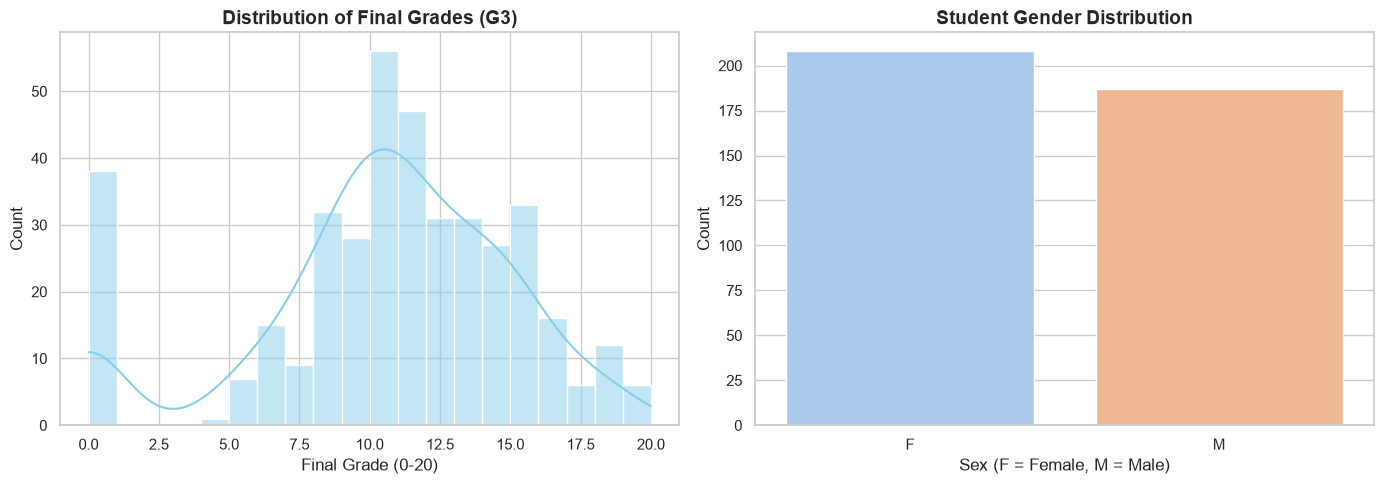

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution of Target Variable (G3)
sns.histplot(df['G3'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Final Grades (G3)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Final Grade (0-20)')
axes[0].set_ylabel('Count')

# 2. Gender Count Plot
sns.countplot(x='sex', hue='sex', data=df, ax=axes[1], palette='pastel', legend=False)
axes[1].set_title('Student Gender Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sex (F = Female, M = Male)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

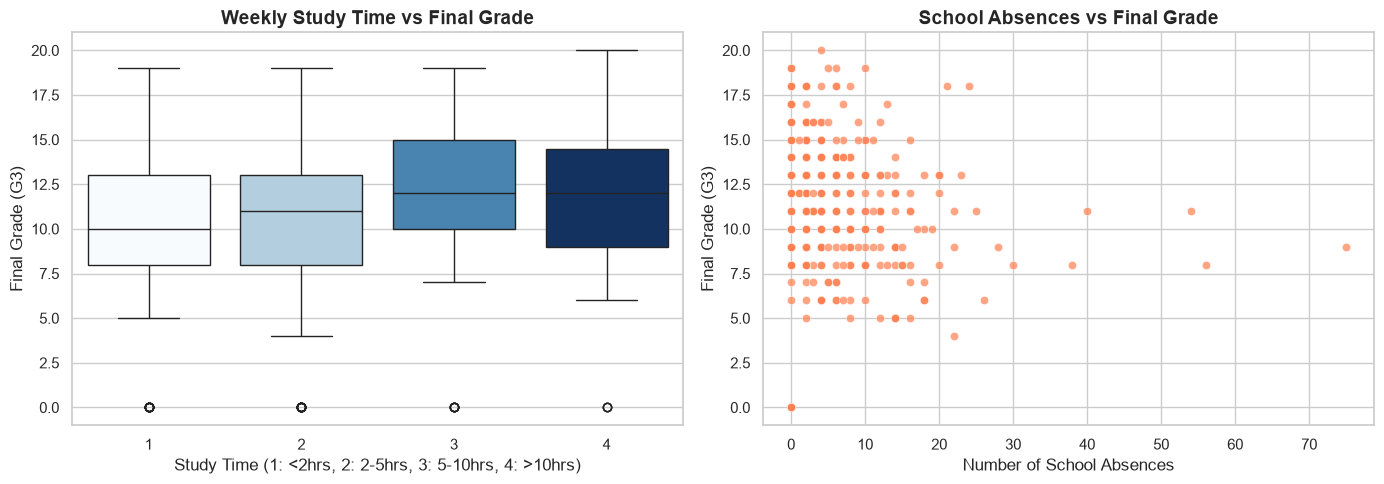

In [8]:
# Set up a figure for bivariate plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Study Time vs Final Grade (G3)
sns.boxplot(x='studytime', y='G3', hue='studytime', data=df, ax=axes[0], palette='Blues',legend=False)
axes[0].set_title('Weekly Study Time vs Final Grade', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Study Time (1: <2hrs, 2: 2-5hrs, 3: 5-10hrs, 4: >10hrs)')
axes[0].set_ylabel('Final Grade (G3)')

# 2. Absences vs Final Grade (G3)
sns.scatterplot(x='absences', y='G3', data=df, ax=axes[1], color='coral', alpha=0.7)
axes[1].set_title('School Absences vs Final Grade', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of School Absences')
axes[1].set_ylabel('Final Grade (G3)')

plt.tight_layout()
plt.show()